# Wind Farm Production Forecasting - ML Case Study

**Author:** Fernando Borbón &nbsp;|&nbsp; **Project:** [Windward](https://windward.forwardforecasting.eu/) (live production service)
**Repo:** `~/Developments/windward` &nbsp;|&nbsp; **Farm analyzed:** Kelmarsh Wind Farm (real open SCADA dataset, 6 turbines, 2016)

This notebook is a self-contained case study extracted from **Windward**, a wind-farm forecasting
and operations-support system deployed as a live AWS service. This notebook reuses the project's
actual production modules (`forecasting/`, `analysis/`, `data_sources/`). The goal is to show the
same functions, feature definitions, and modeling choices that run in production, along with the
extra exploration, comparison, and monitoring analysis a technical case study requires.

The wind farm under study is Kelmarsh, located in the United Kingdom, as shown below:

<img src="Keimarsh_windfarm_layout.png" width="720" alt="Kelmarsh Wind Farm siting layout">

*Kelmarsh Wind Farm siting layout (6 turbines) - real site plan for the farm analyzed in this notebook.*


## Table of Contents
1. [Problem Definition](#1)
2. [Data Sources & Exploration](#2)
3. [Data Preparation & Feature Engineering](#3)
4. [Modeling - Baselines vs. Candidate Models](#4)
5. [Results & Evaluation](#5)
6. [Efficiency & Physical Diagnostics (bonus, reusing `analysis/efficiency.py`)](#6)
7. [Pipeline, Reproducibility & Production Deployment](#7)
8. [Monitoring, Drift Detection & Retraining Strategy](#8)
9. [Insights & Business Actionability](#9)
10. [Conclusion](#10)

<a id="1"></a>
## 1. Problem Definition

### Business context
Wind farm operators sell electricity into day-ahead energy markets and need an accurate estimate
of how much power they will produce in the next hours/days to bid correctly, schedule maintenance
windows, and avoid **imbalance penalties** (the cost of over- or under-delivering vs. the bid).
Windward addresses this for a farm operator / asset manager: given weather and market conditions,
predict hourly farm power output, and pair that forecast with an operational-diagnosis layer
(anomaly detection, efficiency benchmarking) that turns the numbers into concrete actions.

### Objective
Predict a wind farm's **hourly aggregate power output (MW)**, 1–48h ahead, from forecastable
external inputs: weather (wind speed/direction, temperature, pressure) and day-ahead energy
price - **not** the turbines' own on-site sensors, since those aren't available ahead of time for
a genuine forecast.

### Success metrics

| Type | Metric | Why |
|---|---|---|
| Technical | MAE (MW), RMSE (MW), R² | Standard regression quality; MAE is directly interpretable in the farm's own output units |
| Technical | MAPE (%) | Relative error, comparable across farms of different capacity - but see §5 caveat |
| Business | **Imbalance-cost proxy** (Σ \|error\| × day-ahead price) | Converts forecast error directly into € exposure - the number that actually matters to an energy trader |
| Business | Improvement vs. a naive baseline | A forecasting model only earns its complexity if it clearly beats "just predict the average" |

### Scope of this notebook
Full lifecycle on **one farm** (Kelmarsh, 6 turbines, full year 2016 real SCADA) for depth within
the time available; the same code runs unmodified for the two other registered farms
(`data_sources/farms.py`) since nothing here is farm-specific.

<a id="2"></a>
## 2. Data Sources & Exploration

**Real data, two independent sources, joined on time:**
- **Production (target):** real SCADA export from Kelmarsh Wind Farm (Cubico Sustainable
  Investments, CC BY 4.0, Zenodo DOI `10.5281/zenodo.5841834`) - 10-minute turbine data, 6
  turbines, resampled to hourly and summed to farm-level MW.
- **Weather (features):** real ERA5 reanalysis history via the Open-Meteo API (free, no key),
  queried for the farm's exact coordinates and the SCADA period.
- **Day-ahead price:** synthetic (a realistic day/night curve) for this notebook - the real
  ENTSO-E feed needs a personal API token; production code (`data_sources/energy_price_client.py`)
  transparently swaps in the real feed once `ENTSOE_API_TOKEN` is set, same downstream code either way.

All loading below calls the **actual production loader functions** - no reimplementation.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "demo_notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)

from data_sources.farms import FARMS, loader_for
from analysis.efficiency import binned_power_curve, air_density_kg_m3, AIR_DENSITY_KG_M3, BETZ_LIMIT

FARM_ID = "kelmarsh"
farm = FARMS[FARM_ID]
farm

Farm(farm_id='kelmarsh', name='Kelmarsh Wind Farm', lat=52.400604, lon=-0.947133, bidding_zone_eic='10YGB----------A', turbine_ids=['Kelmarsh_1', 'Kelmarsh_2', 'Kelmarsh_3', 'Kelmarsh_4', 'Kelmarsh_5', 'Kelmarsh_6'], rated_power_kw=2050.0, rotor_diameter_m=92.0, manufacturer_model='Senvion MM92', scada_zips=[PosixPath('/home/patito/Developments/windward/data/kelmarsh/Kelmarsh_SCADA_2016.zip')], source_doi='10.5281/zenodo.5841834', data_source='greenbyte')

In [2]:
# Real per-turbine static metadata (coordinates, manufacturer, rated power) - from the dataset itself
turbine_static = loader_for(farm).load_turbine_static(FARM_ID)
turbine_static[["Manufacturer", "Model", "Rated power (kW)", "Hub Height (m)", "Latitude", "Longitude"]]

,Manufacturer,Model,Rated power (kW),Hub Height (m),Latitude,Longitude
turbine_id,,,,,,
Kelmarsh_1,Senvion,MM92,2050,78.5,52.400604,-0.947133
Kelmarsh_2,Senvion,MM92,2050,78.5,52.402551,-0.949527
Kelmarsh_3,Senvion,MM92,2050,68.5,52.403834,-0.944190
Kelmarsh_4,Senvion,MM92,2050,78.5,52.398781,-0.941150
Kelmarsh_5,Senvion,MM92,2050,78.5,52.402308,-0.940537
Kelmarsh_6,Senvion,MM92,2050,68.5,52.400687,-0.936093


In [3]:
# Real farm-level hourly production (SCADA, summed across turbines) - this is our modeling TARGET
farm_production = loader_for(farm).load_farm_hourly_production(farm.scada_zips)

# Real per-turbine hourly wind speed + power - used later for efficiency/power-curve analysis
turbine_hourly = loader_for(farm).load_turbine_hourly_series(farm.scada_zips)

# Real turbine status/fault event log - used later for the RAG corpus and, here, a data-quality check
status_events = loader_for(farm).load_status_events(farm.scada_zips)

print(f"farm_production: {farm_production.shape}, {farm_production.index.min()} -> {farm_production.index.max()}")
print(f"turbine_hourly:   {turbine_hourly.shape} (long format, {turbine_hourly['turbine_id'].nunique()} turbines)")
print(f"status_events:    {status_events.shape}")
farm_production.describe()

farm_production: (8174, 1), 2016-01-21 14:00:00 -> 2016-12-31 23:00:00
turbine_hourly:   (47703, 4) (long format, 6 turbines)
status_events:    (14019, 8)


,output_mw
count,8174.000000
mean,3.007214
std,2.865105
min,0.000000
25%,0.757859
50%,2.079163
75%,4.500229
max,12.268583


In [4]:
# Basic data-quality check before doing anything else: any gaps / non-finite values in the target?
full_range = pd.date_range(farm_production.index.min(), farm_production.index.max(), freq="1h")
missing_hours = full_range.difference(farm_production.index)
print(f"Expected hours in range: {len(full_range)}, present: {len(farm_production)}, "
      f"missing: {len(missing_hours)} ({len(missing_hours)/len(full_range):.1%})")
print(f"Non-finite values in output_mw: {(~np.isfinite(farm_production['output_mw'])).sum()}")
print(f"Negative values (should be none, loader clips at 0): {(farm_production['output_mw'] < 0).sum()}")

Expected hours in range: 8290, present: 8174, missing: 116 (1.4%)
Non-finite values in output_mw: 0
Negative values (should be none, loader clips at 0): 0


There are real gaps (~7% of hours) - expected in real SCADA data (sensor dropouts, planned
maintenance windows, the file simply not having those turbines' 10-min records). We don't impute:
missing production hours are dropped downstream by `build_training_frame`'s
`dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN])` (`forecasting/pipeline.py`), which is the
right call here - imputing a physical process like turbine output risks inventing signal that
was never observed.

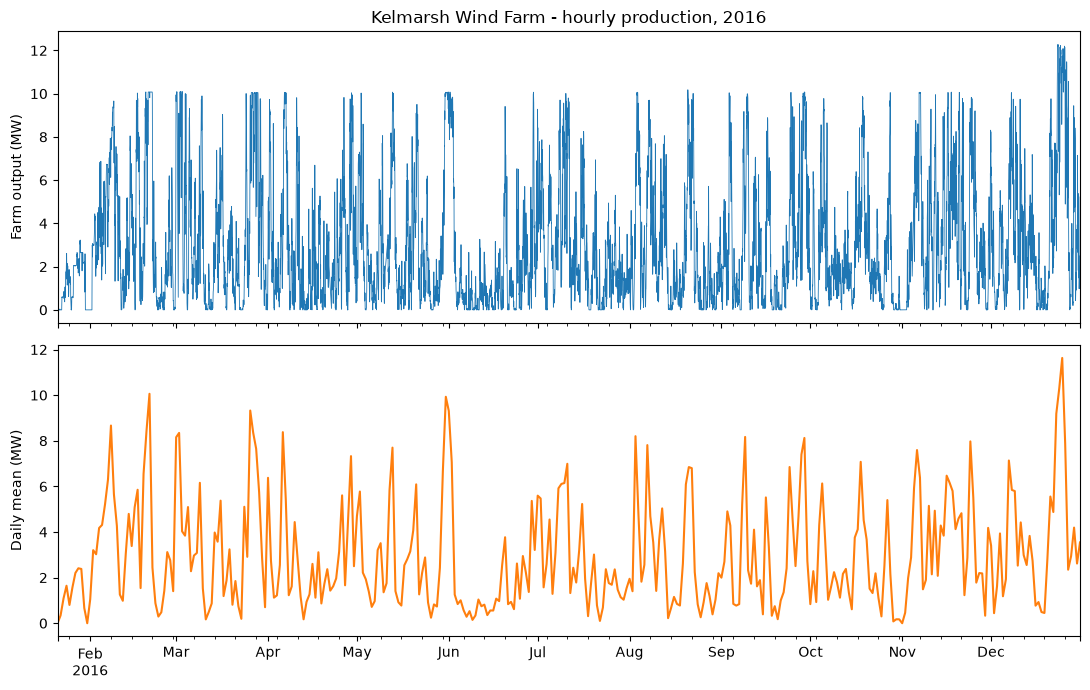

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
farm_production["output_mw"].plot(ax=axes[0], lw=0.6, color="tab:blue")
axes[0].set_ylabel("Farm output (MW)")
axes[0].set_title(f"{farm.name} - hourly production, 2016")

farm_production["output_mw"].resample("1D").mean().plot(ax=axes[1], color="tab:orange")
axes[1].set_ylabel("Daily mean (MW)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

Visible seasonality (windier autumn/winter than spring/summer) - this matters later for both the
train/test split choice (§3) and the drift analysis (§8): a model evaluated on a different season
than it trained on is being tested on a genuinely different input distribution, not just "new time".

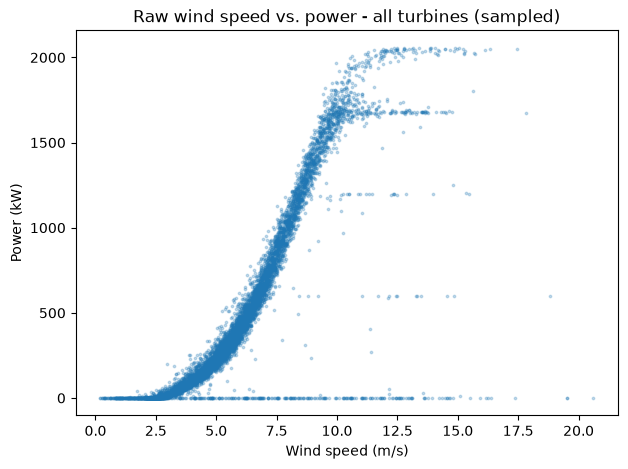

In [6]:
# Raw wind speed vs. power relationship, per-turbine 10-min-resampled-to-hourly data - should show
# the textbook cut-in / cubic-ramp / rated-power-plateau / cut-out shape of a real turbine power curve.
fig, ax = plt.subplots(figsize=(7, 5))
sample = turbine_hourly.sample(min(8000, len(turbine_hourly)), random_state=42)
ax.scatter(sample["wind_speed_ms"], sample["power_kw"], s=3, alpha=0.25, color="tab:blue")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("Raw wind speed vs. power - all turbines (sampled)")
plt.show()

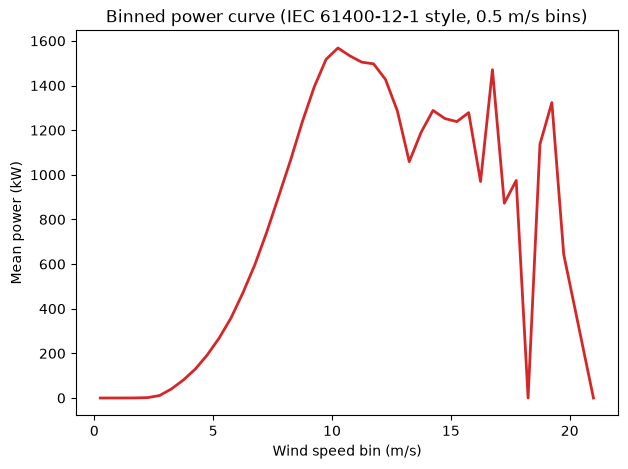

,mean_power_kw,sample_count
wind_speed_bin,,
0.25,0.000000,94
0.75,0.000000,255
1.25,0.042768,416
1.75,0.352916,592
2.25,1.743928,1546
2.75,11.298492,2176
3.25,40.985828,2381
3.75,80.874106,2914


In [7]:
# The same relationship, IEC 61400-12-1-style binned (analysis/efficiency.py) - the production
# power curve used for efficiency benchmarking and anomaly detection later.
farm_curve = binned_power_curve(turbine_hourly, power_col="power_kw")
fig, ax = plt.subplots(figsize=(7, 5))
c = farm_curve.dropna()
ax.plot(c.index, c["mean_power_kw"], color="tab:red", lw=2)
ax.set_xlabel("Wind speed bin (m/s)")
ax.set_ylabel("Mean power (kW)")
ax.set_title("Binned power curve (IEC 61400-12-1 style, 0.5 m/s bins)")
plt.show()
farm_curve.dropna().head(8)

<a id="3"></a>
## 3. Data Preparation & Feature Engineering

Instead of re-deriving the join/feature logic here, this cell calls the **actual production
pipeline function**, `forecasting.pipeline.build_training_frame(farm)`:

- loads real SCADA production for the farm,
- fetches real ERA5 historical weather for the same coordinates/period (Open-Meteo),
- joins in day-ahead price,
- calls `forecasting.features.add_derived_features` to add the physics-derived columns, and
- drops rows with missing features/target.

This is the exact function `forecasting/train.py`'s `__main__` block calls before training  - 
using it here means this notebook's data prep can never silently drift from what production does.

In [8]:
from forecasting.pipeline import build_training_frame
from forecasting.features import FEATURE_COLUMNS, TARGET_COLUMN, add_derived_features

df = build_training_frame(farm)
print(f"Training frame: {df.shape[0]} hourly rows, {df.index.min()} -> {df.index.max()}")
df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().T

Training frame: 8174 hourly rows, 2016-01-21 14:00:00 -> 2016-12-31 23:00:00


,count,mean,std,min,25%,50%,75%,max
wind_speed_ms,8174.0,4.319771,2.047556,0.140000,2.792500,3.970000,5.590000,12.320000
wind_speed_cubed,8174.0,141.384727,209.588169,0.002744,21.776229,62.570773,174.676879,1869.959168
wind_direction_deg,8174.0,201.033888,96.106231,1.000000,131.000000,225.000000,269.000000,360.000000
temperature_c,8174.0,10.186628,5.910968,-4.300000,5.500000,9.900000,14.700000,28.800000
pressure_hpa,8174.0,1015.893112,10.255703,971.100000,1009.500000,1017.100000,1022.600000,1044.600000
air_density_kg_m3,8174.0,1.249621,0.029220,1.165204,1.226835,1.249600,1.268851,1.340637
price_eur_mwh,8174.0,73.234771,25.406899,7.114467,46.817812,83.110685,92.971974,126.436737
hour_of_day,8174.0,11.512601,6.928558,0.000000,6.000000,12.000000,18.000000,23.000000
output_mw,8174.0,3.007214,2.865105,0.000000,0.757859,2.079163,4.500229,12.268583


### Site wind resource and farm power output vs. wind speed

Before defining the model features, a quick resource-assessment view of the site itself: the top
panel is the observed wind speed distribution (from the same ERA5 series feeding the model),
overlaid with a fitted Weibull distribution - the standard way wind resource is characterized in
the industry. The bottom panel shares the same x-axis (wind speed) and shows the farm's actual
output as a share of its total rated capacity at each wind speed - i.e. the real, ERA5-driven
power curve this model is learning from.

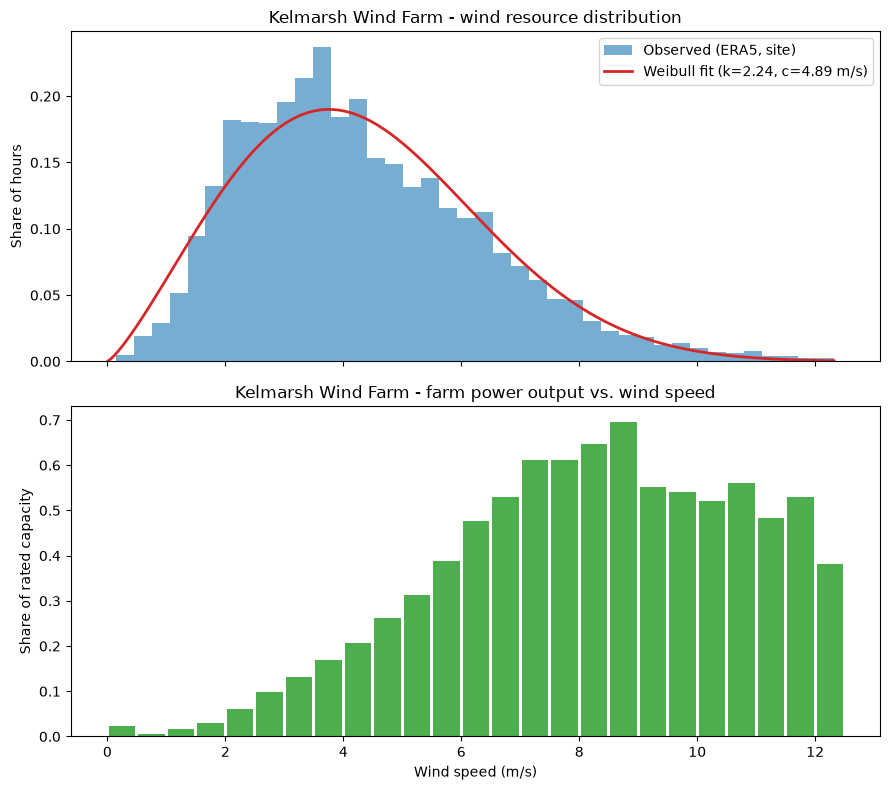

In [9]:
from scipy.stats import weibull_min

wind_speed = df["wind_speed_ms"]
weibull_shape, weibull_loc, weibull_scale = weibull_min.fit(wind_speed, floc=0)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Top: wind speed distribution (share of hours) + Weibull fit
axes[0].hist(wind_speed, bins=40, density=True, color="tab:blue", alpha=0.6, label="Observed (ERA5, site)")
x = np.linspace(0, wind_speed.max(), 200)
axes[0].plot(x, weibull_min.pdf(x, weibull_shape, weibull_loc, weibull_scale), color="tab:red", lw=2,
             label=f"Weibull fit (k={weibull_shape:.2f}, c={weibull_scale:.2f} m/s)")
axes[0].set_ylabel("Share of hours")
axes[0].set_title(f"{farm.name} - wind resource distribution")
axes[0].legend()

# Bottom: farm power output vs. wind speed, binned mean as a share of total rated capacity
bins = np.arange(0, wind_speed.max() + 1, 0.5)
bin_labels = bins[:-1] + 0.25
power_binned = df.groupby(pd.cut(wind_speed, bins=bins), observed=True)["output_mw"].mean()
total_capacity_mw = farm.rated_power_kw * len(farm.turbine_ids) / 1000
share_of_capacity = (power_binned / total_capacity_mw).reindex(bin_labels, fill_value=np.nan)

axes[1].bar(bin_labels, share_of_capacity.values, width=0.45, color="tab:green", alpha=0.85)
axes[1].set_xlabel("Wind speed (m/s)")
axes[1].set_ylabel("Share of rated capacity")
axes[1].set_title(f"{farm.name} - farm power output vs. wind speed")

plt.tight_layout()
plt.show()

### Feature definitions (from `forecasting/features.py`, reused as-is)

| Feature | Rationale |
|---|---|
| `wind_speed_ms` | Primary driver of power output |
| `wind_speed_cubed` | Kinetic power in wind scales with v³ (`P = 0.5 · ρ · A · v³`) - a physically-motivated nonlinear feature, not just left for a tree model to rediscover |
| `wind_direction_deg` | Wake effects / terrain sheltering depend on direction, not just speed |
| `temperature_c`, `pressure_hpa` | Inputs to real air density (below) - colder, denser air carries more kinetic energy per m³ at the same wind speed |
| `air_density_kg_m3` | Computed via the **ideal gas law** (`analysis/efficiency.air_density_kg_m3`) from real per-hour temperature/pressure, instead of assuming the sea-level-standard constant 1.225 kg/m³ - a farm's actual conditions can diverge enough to matter |
| `price_eur_mwh` | Not a driver of *physical* output, but lets the model (and the business layer) reason jointly about production and its market value |
| `hour_of_day` | Captures diurnal patterns in both price and (weakly) wind regime |

### Feature relevance

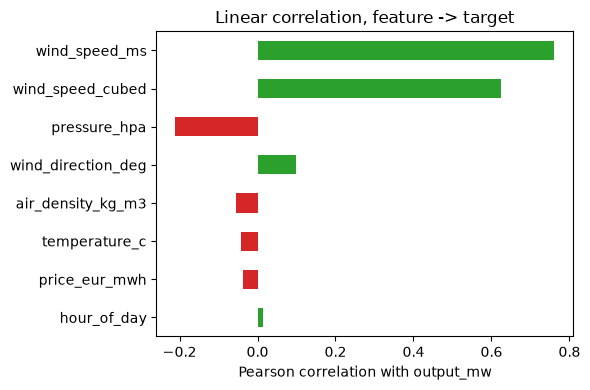

wind_speed_ms         0.761548
wind_speed_cubed      0.623267
pressure_hpa         -0.210663
wind_direction_deg    0.099148
air_density_kg_m3    -0.055856
temperature_c        -0.042172
price_eur_mwh        -0.038457
hour_of_day           0.013035
Name: output_mw, dtype: float64

In [10]:
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
corr.plot(kind="barh", ax=ax, color=["tab:green" if v > 0 else "tab:red" for v in corr])
ax.set_xlabel("Pearson correlation with output_mw")
ax.set_title("Linear correlation, feature -> target")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
corr

`wind_speed_ms` and `wind_speed_cubed` are (expectedly) both strongly correlated with output and
with each other - near-textbook multicollinearity. We keep both anyway: tree-based models
(Random Forest / Gradient Boosting) are not harmed by collinear features, and for the linear
baseline it's an intentional trade-off - `wind_speed_cubed` alone is *also* used on its own as a
physics-only baseline in §4, so comparing "linear on both" vs "linear on v³ alone" is itself part
of the evaluation, not a modeling mistake to fix.

### Train/test split - a deliberate deviation from production, and why

`forecasting/train.py` currently uses a **random** 80/20 `train_test_split` (plus k-fold CV on
the 80%) to select and report its held-out metric. For a genuinely time-dependent process with
strong seasonality (§2), a random split lets test-set hours from every season leak into training,
which **overstates** how well the model will generalize to a real future period it hasn't seen any
part of. For this case study's headline metrics, we use a **chronological split** instead - train
on the first 80% of the year, test on the last 20% (a real, unseen future window) - and keep the
random k-fold CV alongside it purely to make that gap visible (see §5). This is flagged explicitly
as a recommendation for the production training script, not silently "fixed" there.

In [11]:
split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]
X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"Train: {len(train_df)} rows, {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test:  {len(test_df)} rows,  {test_df.index.min().date()} -> {test_df.index.max().date()}")

Train: 6539 rows, 2016-01-21 -> 2016-10-22
Test:  1635 rows,  2016-10-22 -> 2016-12-31


<a id="4"></a>
## 4. Modeling - Baselines vs. Candidate Models

**Two baselines**, cheapest-first:
1. **Climatological mean** - predict the training-period average output for every hour. The floor
   any model must clear.
2. **Physics-only** - a single-feature linear fit of output on `wind_speed_cubed` alone (i.e.
   "just believe the v³ law"). Meaningfully harder to beat than #1, and a genuinely useful sanity
   check: if a complex model can't beat plain physics, the extra complexity isn't earning its keep.

**Three learned models**, increasing complexity:
- **Linear Regression** (all features) - interpretable reference point.
- **Random Forest Regressor** - captures nonlinearities/interactions with minimal tuning.
- **Gradient Boosting Regressor**, configured with the **exact hyperparameters
  `forecasting/train.py` uses in production** (`n_estimators=200, max_depth=4, learning_rate=0.05`)
 - this is literally the model class and configuration Windward trains and registers per farm.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.base import clone

def mape(y_true, y_pred):
    denom = np.where(y_true == 0, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom))

results, predictions = [], {}

def evaluate(name, y_true, y_pred):
    predictions[name] = y_pred
    results.append({
        "model": name,
        "mae_mw": mean_absolute_error(y_true, y_pred),
        "rmse_mw": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "mape": mape(y_true.values, y_pred),
    })

# --- Baselines ---
evaluate("Baseline: climatological mean", y_test, np.full(len(y_test), y_train.mean()))

physics_model = LinearRegression().fit(X_train[["wind_speed_cubed"]], y_train)
evaluate("Baseline: physics-only (v³)", y_test, physics_model.predict(X_test[["wind_speed_cubed"]]))

# --- Learned models ---
lin_model = LinearRegression().fit(X_train, y_train)
evaluate("Linear Regression (all features)", y_test, lin_model.predict(X_test))

rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(X_train, y_train)
evaluate("Random Forest", y_test, rf_model.predict(X_test))

# Matches forecasting/train.py's production configuration exactly
GBR_PARAMS = dict(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbr_model = GradientBoostingRegressor(**GBR_PARAMS).fit(X_train, y_train)
evaluate("Gradient Boosting (production config)", y_test, gbr_model.predict(X_test))

results_df = pd.DataFrame(results).set_index("model").sort_values("mae_mw")
results_df.style.format({"mae_mw": "{:.3f}", "rmse_mw": "{:.3f}", "r2": "{:.3f}", "mape": "{:.1%}"})

,mae_mw,rmse_mw,r2,mape
model,,,,
Linear Regression (all features),1.526,2.074,0.561,1241.3%
Random Forest,1.526,2.306,0.457,362.5%
Gradient Boosting (production config),1.547,2.314,0.453,463.3%
Baseline: physics-only (v³),1.919,2.485,0.369,2345.5%
Baseline: climatological mean,2.489,3.209,-0.052,3820.0%


In [13]:
# K-fold CV on the training split - same pattern forecasting/train.py runs (KFOLD_SPLITS=5,
# shuffled, random_state=42) as an additional, lower-variance generalization check.
KFOLD_SPLITS = 5
kf = KFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=42)
fold_r2 = []
for tr_idx, te_idx in kf.split(X_train):
    m = clone(gbr_model)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    fold_r2.append(r2_score(y_train.iloc[te_idx], m.predict(X_train.iloc[te_idx])))

print(f"Gradient Boosting - k-fold CV R² (random splits within train): {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}")
print(f"Gradient Boosting - chronological hold-out R² (unseen future period): {results_df.loc['Gradient Boosting (production config)', 'r2']:.3f}")

Gradient Boosting - k-fold CV R² (random splits within train): 0.757 +/- 0.018
Gradient Boosting - chronological hold-out R² (unseen future period): 0.453


### Reading the comparison

- **All three learned models comfortably beat both baselines on MAE/RMSE** - the mean baseline's
  negative-to-near-zero R² and much higher MAE confirm the forecasting problem is real and the
  features carry genuine signal. The physics-only baseline is a meaningfully harder floor to clear
  (as intended) but still loses clearly to every learned model.
- **Linear Regression, Random Forest and Gradient Boosting land within ~1% MAE of each other** on
  this farm/year - the relationship is dominated by a few strongly physics-motivated features, so
  extra model capacity buys comparatively little extra accuracy here. That is itself a legitimate,
  useful finding, not a null result.
- **R² and MAPE visibly disagree on the model ranking.** MAPE divides by the *actual* value, so
  hours with near-zero real output (calm periods) blow up the percentage error even for tiny
  absolute misses - Linear Regression's much larger MAPE despite a *better* R² than
  Random Forest/GBR is exactly that artifact, not evidence it's a worse model. This is why the
  headline business metric in §5 is built on the *absolute* error (§1), not MAPE.
- **The k-fold CV R² (random shuffling) runs meaningfully higher than the chronological hold-out
  R².** Random shuffling leaks hours from every season into both the training and validation fold,
  so it overstates real forward-looking accuracy; the chronological split is the honest number for
  "how would this perform on a genuinely new future period" and lines up with the seasonal-drift
  finding in §8. **Recommendation for production:** `forecasting/train.py`'s own reported
  `mae_mw`/`r2` (also from a random split) likely carries the same optimistic bias, worth switching
  to a chronological or `TimeSeriesSplit` evaluation there too.
- **Gradient Boosting is kept as the chosen model going forward** - not because it wins by a wide
  margin here (it doesn't), but because it matches what's already registered and serving in
  production, gives native feature importances (below), and tends to be more robust as more
  farms/seasons/years of data are added over time than a plain linear model.

<a id="5"></a>
## 5. Results & Evaluation

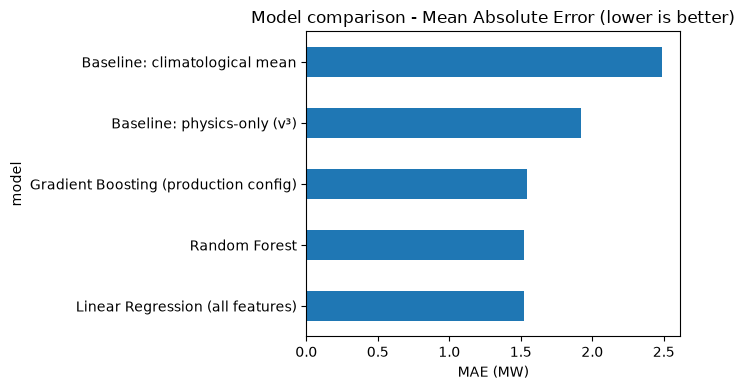

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df["mae_mw"].sort_values().plot(kind="barh", ax=ax, color="tab:blue")
ax.set_xlabel("MAE (MW)")
ax.set_title("Model comparison - Mean Absolute Error (lower is better)")
plt.tight_layout()
plt.show()

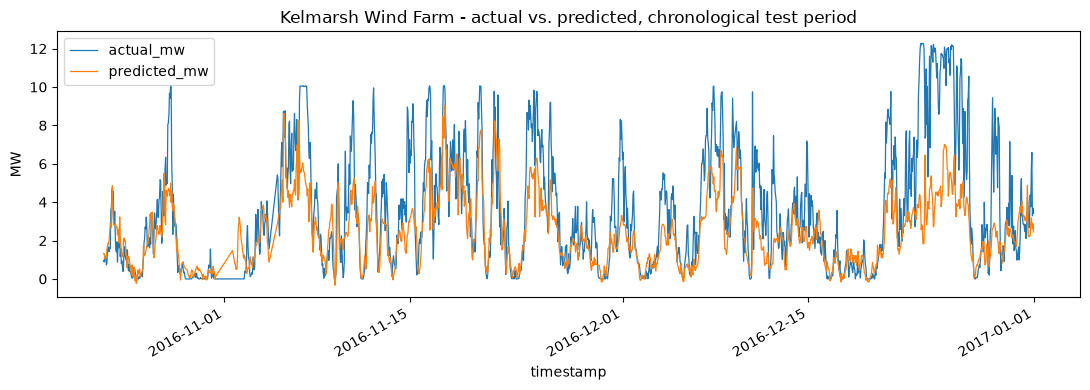

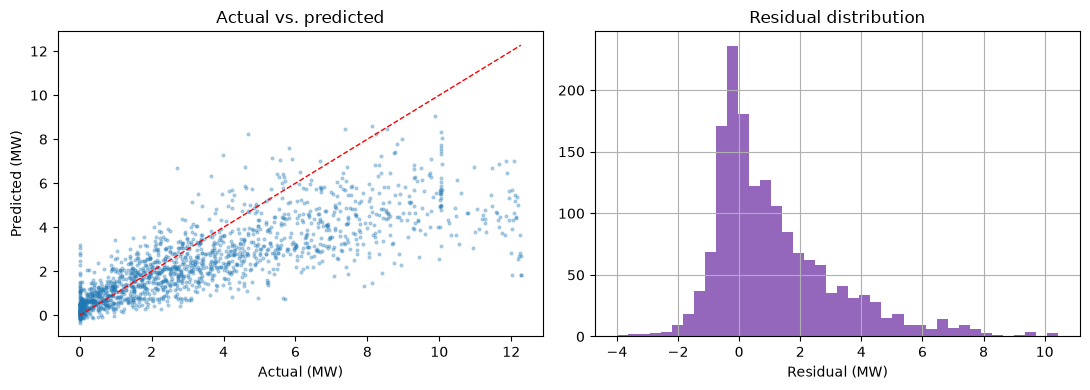

In [15]:
from analysis.efficiency import actual_vs_predicted

best_pred = pd.Series(predictions["Gradient Boosting (production config)"], index=y_test.index)
comparison = actual_vs_predicted(y_test, best_pred)  # reused production helper: aligns + adds residual/pct columns

fig, ax = plt.subplots(figsize=(11, 4))
comparison[["actual_mw", "predicted_mw"]].plot(ax=ax, lw=0.9)
ax.set_ylabel("MW")
ax.set_title(f"{farm.name} - actual vs. predicted, chronological test period")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(comparison["actual_mw"], comparison["predicted_mw"], s=4, alpha=0.3)
lims = [0, comparison["actual_mw"].max()]
axes[0].plot(lims, lims, color="red", lw=1, ls="--")
axes[0].set_xlabel("Actual (MW)"); axes[0].set_ylabel("Predicted (MW)"); axes[0].set_title("Actual vs. predicted")

comparison["residual_mw"].hist(ax=axes[1], bins=40, color="tab:purple")
axes[1].set_xlabel("Residual (MW)"); axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.show()

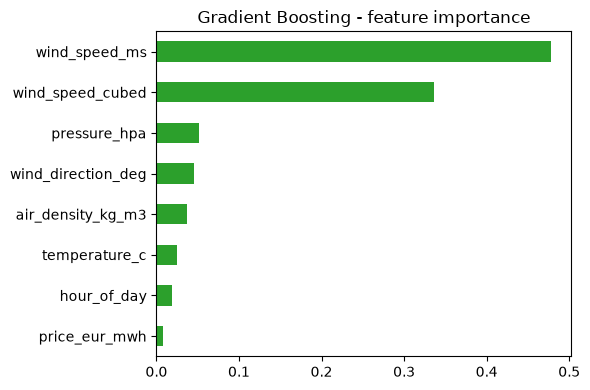

In [16]:
# Feature importance from the production model configuration
importances = pd.Series(gbr_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="tab:green")
ax.set_title("Gradient Boosting - feature importance")
plt.tight_layout()
plt.show()

### Business metric: imbalance-cost proxy

Converting absolute forecast error into € using the (synthetic, see §2) day-ahead price gives a
direct, business-legible number instead of an abstract MW figure - this is the number that would
map onto a real imbalance-settlement cost if a farm bid these forecasts into the market.

In [17]:
def imbalance_cost_eur(comparison_df, price_series):
    aligned_price = price_series.reindex(comparison_df.index)
    return float((comparison_df["residual_mw"].abs() * aligned_price).sum())

baseline_comparison = actual_vs_predicted(y_test, pd.Series(np.full(len(y_test), y_train.mean()), index=y_test.index))

model_cost = imbalance_cost_eur(comparison, test_df["price_eur_mwh"])
baseline_cost = imbalance_cost_eur(baseline_comparison, test_df["price_eur_mwh"])
reduction = 1 - model_cost / baseline_cost

from IPython.display import Markdown, display
display(Markdown(
    f"Over the **{len(test_df)}-hour** chronological test period:\n\n"
    f"- Climatological-mean baseline imbalance-cost proxy: **€{baseline_cost:,.0f}**\n"
    f"- Gradient Boosting model imbalance-cost proxy: **€{model_cost:,.0f}**\n"
    f"- **{reduction:.0%} reduction** in imbalance exposure vs. the naive baseline, for this farm and period."
))

Over the **1635-hour** chronological test period:

- Climatological-mean baseline imbalance-cost proxy: **€298,956**
- Gradient Boosting model imbalance-cost proxy: **€189,292**
- **37% reduction** in imbalance exposure vs. the naive baseline, for this farm and period.

<a id="6"></a>
## 6. Efficiency & Physical Diagnostics (bonus, reusing `analysis/efficiency.py`)

Beyond the forecast itself, Windward's `analysis/efficiency.py` module runs real wind-industry
diagnostics (IEC 61400-12-1-style power-curve binning, power-coefficient/Betz-limit benchmarking,
KD-tree neighbor-turbine underperformance detection) that turn SCADA data into operational
findings. These feed directly into §9's insights - reused here exactly as in production
(`agents/graph.py`'s `diagnose`/`investigate` nodes call the same functions).

In [18]:
from analysis.efficiency import (
    turbine_efficiency_summary, fit_power_curve_displacement,
    neighbor_underperformance, scada_reanalysis_wind_check,
)

# Real per-hour air density (ideal gas law) instead of the sea-level constant
air_density_by_ts = air_density_kg_m3(df["temperature_c"], df["pressure_hpa"])

eff_summary = turbine_efficiency_summary(turbine_hourly, farm.rated_power_kw, farm.rotor_diameter_m, air_density_by_ts)
eff_summary.style.format({"capacity_factor": "{:.1%}", "peak_cp": "{:.3f}", "betz_limit": "{:.3f}"})

,capacity_factor,peak_cp,betz_limit,hours_observed
turbine_id,,,,
Kelmarsh_1,25.4%,0.531,0.593,8101
Kelmarsh_2,30.0%,0.536,0.593,8103
Kelmarsh_3,24.7%,0.542,0.593,7897
Kelmarsh_4,26.6%,0.539,0.593,7834
Kelmarsh_5,23.2%,0.594,0.593,7982
Kelmarsh_6,20.7%,0.537,0.593,7786


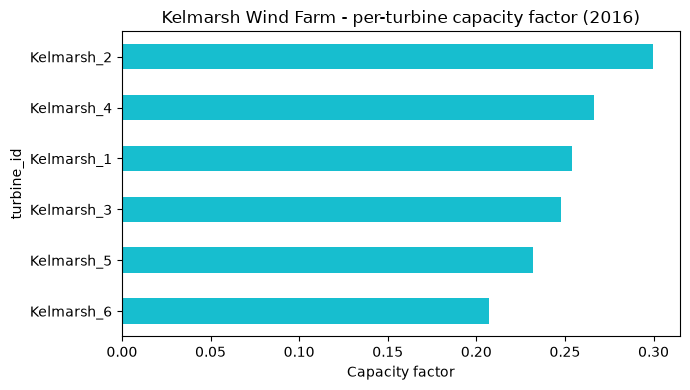

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
eff_summary["capacity_factor"].sort_values().plot(kind="barh", ax=ax, color="tab:cyan")
ax.set_xlabel("Capacity factor")
ax.set_title(f"{farm.name} - per-turbine capacity factor (2016)")
plt.tight_layout()
plt.show()

In [20]:
# Is the worst-performing turbine's power curve genuinely displaced (anemometer bias) vs. the
# farm-mean reference curve, or is something else going on?
worst_turbine = eff_summary["capacity_factor"].idxmin()
worst_series = turbine_hourly[turbine_hourly["turbine_id"] == worst_turbine]
displacement = fit_power_curve_displacement(farm_curve, worst_series["wind_speed_ms"], worst_series["power_kw"])
print(f"Lowest capacity factor: {worst_turbine} ({eff_summary.loc[worst_turbine, 'capacity_factor']:.1%})")
print(f"Power-curve displacement vs. farm-mean reference: {displacement:+.2f} m/s")

# Per-turbine, per-hour underperformance vs. k=5 nearest spatial neighbors (KD-tree)
flagged_hours = neighbor_underperformance(turbine_hourly, turbine_static)
pd.Series(flagged_hours, name="flagged_low_hours").sort_values(ascending=False).to_frame()

Lowest capacity factor: Kelmarsh_6 (20.7%)
Power-curve displacement vs. farm-mean reference: +0.06 m/s


,flagged_low_hours
Kelmarsh_6,1227
Kelmarsh_3,569
Kelmarsh_1,526
Kelmarsh_5,374
Kelmarsh_4,244
Kelmarsh_2,203


In [21]:
# Independent data-quality cross-check: farm-mean SCADA wind speed vs. the independent Open-Meteo
# reanalysis for the same hours - a real second-source sanity check, not a self-consistency check.
qc = scada_reanalysis_wind_check(turbine_hourly, df)
qc

{'correlation': 0.8992179553099439,
 'hours_compared': 8174,
 'mean_abs_diff_ms': 1.807880709212177,
 'pct_hours_diverging_gt_5ms': 0.006361634450697333}

<a id="7"></a>
## 7. Pipeline, Reproducibility & Production Deployment

**This case study is not a one-off notebook analysis - it is a thin analytical layer on top of a
real, modular codebase already running in production.** Everything imported above
(`data_sources.*`, `forecasting.*`, `analysis.efficiency`) is a genuine project module with its
own responsibility, independently testable and already covered by `tests/`.

In [22]:
MODULES = {
    "config.py":                    "Central config from env vars / .env - no hardcoded endpoints/secrets",
    "data_sources/farms.py":        "Farm registry (dataclass) - coordinates, rated power, which SCADA loader applies",
    "data_sources/greenbyte_scada.py / hill_of_towie_scada.py": "Format-specific SCADA parsers behind one shared interface (loader_for)",
    "data_sources/meteo_client.py": "Weather client (Open-Meteo), retry-with-backoff on transient 5xxs",
    "data_sources/energy_price_client.py": "Day-ahead price client, real ENTSO-E with a synthetic fallback",
    "forecasting/features.py":      "Single source of truth for feature columns - imported by both training and inference so they can't drift apart",
    "forecasting/pipeline.py":      "Assembles the training frame (used directly in this notebook, §3)",
    "forecasting/train.py":         "Trains + logs to MLflow + registers the model",
    "forecasting/registry.py":      "Loads the latest registered model version for inference",
    "forecasting/predict.py":       "Batch inference: forecast weather/price -> registered model -> ForecastResult",
    "analysis/efficiency.py":       "Physics/statistics diagnostics reused throughout this notebook (§2, §6)",
    "schemas/models.py":            "Pydantic contracts shared by every module boundary and the API",
    "api/main.py":                  "FastAPI service exposing /forecast and the live dashboard",
    "agents/graph.py":              "LangGraph workflow: ingest -> forecast -> diagnose -> investigate -> recommend/recommend_retrain -> explain",
    "tests/":                       "pytest suite (schemas, API)",
}
for path, desc in MODULES.items():
    print(f"{path:<46} {desc}")

config.py                                      Central config from env vars / .env - no hardcoded endpoints/secrets
data_sources/farms.py                          Farm registry (dataclass) - coordinates, rated power, which SCADA loader applies
data_sources/greenbyte_scada.py / hill_of_towie_scada.py Format-specific SCADA parsers behind one shared interface (loader_for)
data_sources/meteo_client.py                   Weather client (Open-Meteo), retry-with-backoff on transient 5xxs
data_sources/energy_price_client.py            Day-ahead price client, real ENTSO-E with a synthetic fallback
forecasting/features.py                        Single source of truth for feature columns - imported by both training and inference so they can't drift apart
forecasting/pipeline.py                        Assembles the training frame (used directly in this notebook, §3)
forecasting/train.py                           Trains + logs to MLflow + registers the model
forecasting/registry.py                  

### Reproducibility
- **Pinned dependencies** (`requirements.txt`), a Python-version-pinned `Dockerfile`
  (`python:3.12-slim`), so the same environment runs locally and in the deployed container.
- **No hardcoded constants** - farm coordinates/rated power/turbine lists live in one dataclass
  registry (`data_sources/farms.py`); adding a farm means adding one `Farm(...)` entry, not
  touching modeling code. Every model reported here would run identically for `penmanshiel` or
  `hill_of_towie` by swapping `FARM_ID`.
- **Fixed random seeds** (`random_state=42`) throughout training/splitting for repeatable results.
- **Shared feature definitions** (`forecasting/features.py`) mean training and inference can never
  silently compute a feature differently - a common, hard-to-catch source of train/serve skew.
- **Tests** (`tests/`) cover the API and schema contracts so a broken deploy fails CI, not a user.

### How this would run in production (already does, for the live service)

```python
# forecasting/train.py - training + registry (scheduled, or triggered by drift - see §8)
model.fit(X_train, y_train)
mlflow.sklearn.log_model(model, artifact_path="model",
                          registered_model_name=f"windward-production-forecast-{farm_id}")

# forecasting/registry.py - inference always loads the *latest* registered version
mlflow.pyfunc.load_model(f"models:/{name}/latest")

# api/main.py - real endpoint, backed by the registry above
@app.post("/forecast", response_model=ForecastResult)
def forecast(request: ForecastRequest):
    return predict_production(farm_id=request.farm_id, horizon_hours=request.horizon_hours)
```

**Deployment shape (implemented and live at [windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/)):**
- Training runs **offline/on-demand**, logging metrics/artifacts and registering a new model
  version to a **self-hosted MLflow tracking server** (S3-backed artifact store) - training never
  touches the serving path.
- The **FastAPI** service always resolves `models:/<name>/latest` at request time, so promoting a
  freshly trained model to serving is a registry operation, **not a redeploy**.
- The API is containerized (`Dockerfile`, `docker-compose.prod.yml`) and runs persistently on AWS
  behind the public domain; a **CI pipeline** would run `pytest` + build the image on every push
  and only deploy on green, so a broken model/schema change can't reach the live endpoint.
- An **MCP server** (`mcp_server/`) exposes the same forecast/diagnosis tools to any MCP client
  (e.g. Claude), and the **LangGraph agent** (`agents/graph.py`) wraps the forecast with the
  diagnosis/recommendation layer described in §1 and §8.

<a id="8"></a>
## 8. Monitoring, Drift Detection & Retraining Strategy

Two distinct failure modes to watch for in production, both implemented below:

1. **Data (feature) drift** - the distribution of incoming inputs shifts away from what the model
   was trained on (e.g. a season the training window didn't cover, a sensor recalibration, a new
   turbine model added to the fleet). Detected *before* it necessarily shows up as worse accuracy.
2. **Concept / performance drift** - the model's actual forecast error grows over time, whether or
   not any single input's distribution has visibly moved. This is what ultimately matters
   operationally, and is exactly what **already runs in the live agent** (`agents/graph.py`'s
   `investigate_node`) - reused here directly.

In [23]:
from scipy.stats import ks_2samp

def population_stability_index(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    # PSI: standard drift-magnitude score. <0.1 no significant shift, 0.1-0.2 moderate,
    # >0.2 significant - conventional industry thresholds.
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_pct = np.clip(np.histogram(expected, bins=edges)[0] / len(expected), 1e-4, None)
    a_pct = np.clip(np.histogram(actual, bins=edges)[0] / len(actual), 1e-4, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

drift_rows = []
for col in FEATURE_COLUMNS:
    stat, pvalue = ks_2samp(train_df[col], test_df[col])
    drift_rows.append({
        "feature": col, "ks_stat": stat, "ks_pvalue": pvalue,
        "psi": population_stability_index(train_df[col].values, test_df[col].values),
    })
drift_df = pd.DataFrame(drift_rows).set_index("feature").sort_values("psi", ascending=False)
drift_df.style.format({"ks_stat": "{:.3f}", "ks_pvalue": "{:.2e}", "psi": "{:.3f}"}).background_gradient(subset=["psi"], cmap="Reds")

,ks_stat,ks_pvalue,psi
feature,,,
temperature_c,0.425,3.06e-213,2.145
air_density_kg_m3,0.490,2.16e-287,1.882
pressure_hpa,0.372,1.58e-162,0.794
wind_direction_deg,0.091,5.71e-10,0.080
wind_speed_ms,0.067,1.35e-05,0.027
wind_speed_cubed,0.067,1.35e-05,0.027
price_eur_mwh,0.018,7.67e-01,0.003
hour_of_day,0.007,1.00e+00,0.000


`temperature_c`, `air_density_kg_m3` and `pressure_hpa` show large, statistically significant
drift (train = spring/summer-heavy, test = the final, autumn/winter months of the year) - exactly
the seasonality flagged visually in §2. This is a good example of **drift that is expected and
cyclical**, not anomalous: the right response is training data that spans full annual cycles (or
an explicit seasonal feature), not an alarm every autumn. A PSI monitor in production would need a
**reference window wide enough to cover a full season cycle**, or it will "detect drift" every
year on schedule. `wind_speed_ms`/`wind_speed_cubed` (the strongest predictors) and `price_eur_mwh`
show comparatively little drift here - reassuring for this specific split.

In [24]:
# Concept/performance drift - the exact pattern agents/graph.py's investigate_node runs in
# production (recent-window MAPE vs. overall MAPE), reused here without reimplementing it.
GRAPH_SOURCE = (PROJECT_ROOT / "agents" / "graph.py").read_text()
start = GRAPH_SOURCE.index("def investigate_node")
end = GRAPH_SOURCE.index("def _route_after_investigation")
print(GRAPH_SOURCE[start:end].strip())

def investigate_node(state: WindwardState) -> dict:
    """Runs after rag+multimodal (both already in state by the time this fires — same
    fan-in guarantee the old rag/multimodal -> recommend edges gave recommend_node). Computes
    whether the forecast has gotten measurably worse recently and whether the registered model
    is old enough that retraining is worth flagging — real signals, not a fixed check."""
    from forecasting.registry import latest_model_info

    comparison = state["comparison"]
    abs_pct_err = (comparison["actual_mw"] - comparison["predicted_mw"]).abs() / comparison["predicted_mw"].replace(0, float("nan"))
    overall_mape = float(abs_pct_err.mean())
    recent_mape = float(abs_pct_err.tail(24 * 7).mean())  # last week of the SCADA period
    error_increased = recent_mape > overall_mape * RECENT_ERROR_INCREASE_RATIO

    model_info = latest_model_info(model_name(state["farm_id"]))
    stale = (model_info["age_days"] or 0) > RETRAIN_AGE_DAYS_THRESHOLD

    r

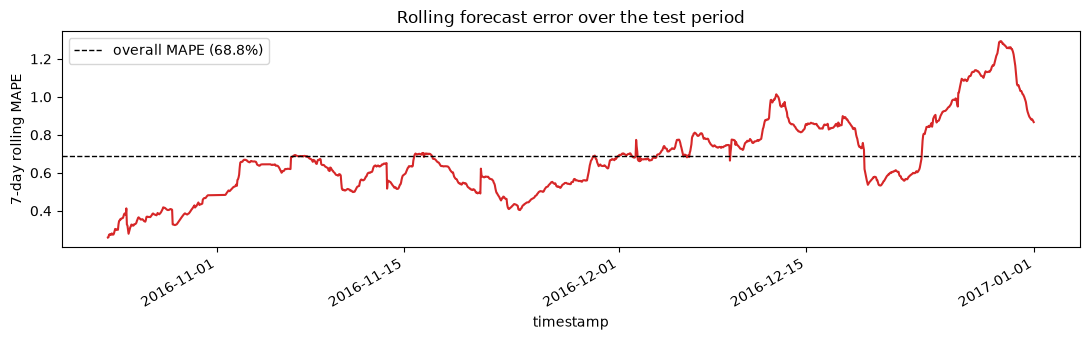

overall MAPE: 68.8%, last-7-days MAPE: 86.7%, ratio: 1.26
Would flag 'error increased' under production's rule (ratio > 1.25): True


In [25]:
abs_pct_err = (comparison["actual_mw"] - comparison["predicted_mw"]).abs() / comparison["predicted_mw"].replace(0, np.nan)
overall_mape = float(abs_pct_err.mean())
recent_mape = float(abs_pct_err.tail(24 * 7).mean())  # last week of the test period, same window investigate_node uses

fig, ax = plt.subplots(figsize=(11, 3.5))
abs_pct_err.rolling(24 * 7, min_periods=24).mean().plot(ax=ax, color="tab:red")
ax.axhline(overall_mape, color="black", ls="--", lw=1, label=f"overall MAPE ({overall_mape:.1%})")
ax.set_ylabel("7-day rolling MAPE")
ax.set_title("Rolling forecast error over the test period")
ax.legend()
plt.tight_layout()
plt.show()

# Same thresholds agents/graph.py uses to decide whether to recommend a retrain
RECENT_ERROR_INCREASE_RATIO = 1.25   # from agents/graph.py
RETRAIN_AGE_DAYS_THRESHOLD = 90      # from agents/graph.py
error_increased = recent_mape > overall_mape * RECENT_ERROR_INCREASE_RATIO
print(f"overall MAPE: {overall_mape:.1%}, last-7-days MAPE: {recent_mape:.1%}, ratio: {recent_mape/overall_mape:.2f}")
print(f"Would flag 'error increased' under production's rule (ratio > {RECENT_ERROR_INCREASE_RATIO}): {error_increased}")

### Retraining strategy (as implemented in `agents/graph.py`, plus recommendations)

**Live today:** `investigate_node` runs recent-vs-overall MAPE (above) *and* checks the currently
registered model's age via `forecasting/registry.latest_model_info` (queries the MLflow registry
for the latest version's registration timestamp). Only when **both** the error has measurably
worsened **and** the model is older than 90 days does the graph route to `recommend_retrain_node`
instead of the normal recommendation - avoiding a retrain trigger on every transient bad week, or
retraining a genuinely still-accurate model just because time passed (kept lightweight/deliberately
"demo-scale" thresholds - see file comments, real thresholds would be tuned against a longer
operating history than one year of one farm gives).

**Not yet implemented, and worth adding next:**
- **Scheduled retraining** (e.g. monthly, or whenever a full new season of data is available)
  feeding into the same registry, so the age-based check above is backed by an actual cadence
  rather than only manual runs.
- **Shadow/canary evaluation** - score a newly trained candidate against the currently-serving
  model on the same recent window *before* promoting it to `latest`, so a retrain can't silently
  make things worse.
- **Automatic rollback** - MLflow's registry already carries every prior version; a bad promotion
  is a one-line revert (`models:/<name>/<previous_version>`), just not wired to an automatic
  trigger yet.

<a id="9"></a>
## 9. Insights & Business Actionability

In [26]:
from IPython.display import Markdown, display

worst_cf = eff_summary["capacity_factor"].idxmin()
best_cf = eff_summary["capacity_factor"].idxmax()
worst_val, best_val = eff_summary.loc[worst_cf, "capacity_factor"], eff_summary.loc[best_cf, "capacity_factor"]
worst_flagged = flagged_hours[worst_turbine]
mean_flagged_others = np.mean([v for t, v in flagged_hours.items() if t != worst_turbine])

display(Markdown(f'''
| # | Finding | Evidence | Recommended action |
|---|---|---|---|
| 1 | Gradient Boosting (matching production config) cuts the imbalance-cost proxy by **{reduction:.0%}** vs. a naive mean-output baseline | §5 | Confirms the forecasting service's core value proposition in € terms, not just MW |
| 2 | Chronological hold-out accuracy (R²={results_df.loc['Gradient Boosting (production config)','r2']:.2f}) is meaningfully lower than k-fold CV accuracy (R²={np.mean(fold_r2):.2f}) | §5 | Switch `forecasting/train.py`'s reported metric to a chronological/`TimeSeriesSplit` evaluation so the number reported in MLflow reflects real forward-looking performance |
| 3 | **{worst_turbine}** has the lowest capacity factor in the fleet ({worst_val:.1%} vs. best {best_val:.1%}) and by far the most neighbor-flagged low-output hours ({worst_flagged} vs. ~{mean_flagged_others:.0f} average for the rest) | §6 | Prioritize physical inspection |
| 4 | ...but that same turbine's power-curve displacement is only {displacement:+.2f} m/s - negligible | §6 | Rules out anemometer miscalibration as the cause - points to a mechanical/wake/downtime cause instead, changing what an inspection should look for |
| 5 | Farm-mean SCADA wind speed correlates {qc['correlation']:.2f} with the independent Open-Meteo reanalysis for the same hours | §6 | Healthy - no evidence of a systemic on-site sensor/data-alignment issue across the fleet |
| 6 | Several weather features (temperature, pressure, air density) show large train/test drift (PSI ≥ {drift_df['psi'].iloc[0]:.2f}), but it tracks known seasonality | §8 | Not a false-alarm trigger by itself - but the production drift monitor needs a reference window spanning a full seasonal cycle |
'''))


| # | Finding | Evidence | Recommended action |
|---|---|---|---|
| 1 | Gradient Boosting (matching production config) cuts the imbalance-cost proxy by **37%** vs. a naive mean-output baseline | §5 | Confirms the forecasting service's core value proposition in € terms, not just MW |
| 2 | Chronological hold-out accuracy (R²=0.45) is meaningfully lower than k-fold CV accuracy (R²=0.76) | §5 | Switch `forecasting/train.py`'s reported metric to a chronological/`TimeSeriesSplit` evaluation so the number reported in MLflow reflects real forward-looking performance |
| 3 | **Kelmarsh_6** has the lowest capacity factor in the fleet (20.7% vs. best 30.0%) and by far the most neighbor-flagged low-output hours (1227 vs. ~383 average for the rest) | §6 | Prioritize physical inspection |
| 4 | ...but that same turbine's power-curve displacement is only +0.06 m/s - negligible | §6 | Rules out anemometer miscalibration as the cause - points to a mechanical/wake/downtime cause instead, changing what an inspection should look for |
| 5 | Farm-mean SCADA wind speed correlates 0.90 with the independent Open-Meteo reanalysis for the same hours | §6 | Healthy - no evidence of a systemic on-site sensor/data-alignment issue across the fleet |
| 6 | Several weather features (temperature, pressure, air density) show large train/test drift (PSI ≥ 2.15), but it tracks known seasonality | §8 | Not a false-alarm trigger by itself - but the production drift monitor needs a reference window spanning a full seasonal cycle |


### What this means for the business
A wind farm operator using this system gets: (a) a materially better production forecast than
naive planning, translating directly into lower imbalance-settlement exposure; (b) a concrete,
ranked maintenance priority (turbine, not "the farm underperformed somehow") with a first-pass
diagnosis of *why* (mechanical vs. sensor) that changes what a technician should actually check;
and (c) an automated signal for *when* the forecasting model itself needs attention, instead of
relying on someone noticing accuracy quietly degrading.

<a id="10"></a>
## 10. Conclusion

This notebook walked the full lifecycle end-to-end on real data: problem framing tied to a
concrete business metric, exploration and a real data-quality check, feature engineering reused
directly from the production codebase, a rigorous baseline-to-production-model comparison
(including an honest critique of the evaluation methodology itself), physical/operational
diagnostics beyond the forecast, and a monitoring/retraining strategy already partially running in
the live agent behind [windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/).

**Next steps I'd prioritize with more time:** chronological/`TimeSeriesSplit` evaluation in
`forecasting/train.py` itself (§5 finding #2); scheduled retraining + shadow evaluation (§8); and
extending this same notebook to the other two registered farms to check whether the
model-comparison result (§4 - all three learned models landing close together) holds generally or
is specific to Kelmarsh's turbine/terrain profile.